# Ir Além 2 - Diagnóstico Visual em Cardiologia com MLP

Este notebook implementa o modulo extra da Fase 2 do CardioIA voltado a classificacao binaria de ECG com rede neural `MLP`.

Usamos o dataset recomendado no enunciado, `heartbeat`, de Shayan Fazeli no Kaggle. Como essa base e distribuida em `CSV`, cada sinal é convertido em uma imagem em tons de cinza antes do treinamento.

## 1. Bibliotecas

Usamos `pandas` para leitura dos dados, `numpy` para processamento numerico, `Pillow` para rasterizar os sinais e `TensorFlow/Keras` para a MLP.

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import keras

## 2. Caminhos e leitura do dataset

Esperamos os arquivos `ptbdb_normal.csv` e `ptbdb_abnormal.csv` dentro de `mlp-ecg/data/heartbeat/`.

In [23]:
PROJECT_ROOT = Path(r'C:\Users\felip\OneDrive\Documentos\Dev\ano2_fase2\CardioIA-FIAP')
DATA_DIR = PROJECT_ROOT / 'mlp-ecg' / 'data' / 'heartbeat'
NORMAL_PATH = DATA_DIR / 'ptbdb_normal.csv'
ABNORMAL_PATH = DATA_DIR / 'ptbdb_abnormal.csv'

print('NORMAL:', NORMAL_PATH, NORMAL_PATH.exists())
print('ABNORMAL:', ABNORMAL_PATH, ABNORMAL_PATH.exists())

assert NORMAL_PATH.exists(), f'Arquivo nao encontrado: {NORMAL_PATH}'
assert ABNORMAL_PATH.exists(), f'Arquivo nao encontrado: {ABNORMAL_PATH}'

normal_df = pd.read_csv(NORMAL_PATH, header=None)
abnormal_df = pd.read_csv(ABNORMAL_PATH, header=None)

print('Normal:', normal_df.shape)
print('Anormal:', abnormal_df.shape)

NORMAL: C:\Users\felip\OneDrive\Documentos\Dev\ano2_fase2\CardioIA-FIAP\mlp-ecg\data\heartbeat\ptbdb_normal.csv True
ABNORMAL: C:\Users\felip\OneDrive\Documentos\Dev\ano2_fase2\CardioIA-FIAP\mlp-ecg\data\heartbeat\ptbdb_abnormal.csv True
Normal: (4046, 188)
Anormal: (10506, 188)


## 3. Preparação da base binária

Cada linha possui 187 amostras do batimento e uma coluna final de classe. Para manter o notebook leve, fazemos um balanceamento simples por amostragem.

In [24]:
MAX_SAMPLES_PER_CLASS = 2500
RANDOM_STATE = 42

normal_sample = normal_df.sample(n=min(MAX_SAMPLES_PER_CLASS, len(normal_df)), random_state=RANDOM_STATE)
abnormal_sample = abnormal_df.sample(n=min(MAX_SAMPLES_PER_CLASS, len(abnormal_df)), random_state=RANDOM_STATE)

signals = pd.concat([normal_sample, abnormal_sample], ignore_index=True)
signals = signals.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_signal = signals.iloc[:, :-1].to_numpy(dtype=np.float32)
y = signals.iloc[:, -1].to_numpy(dtype=np.int32)

print('Total de amostras usadas:', len(X_signal))
print('Formato dos sinais:', X_signal.shape)
print('Distribuicao das classes:', {0: int((y == 0).sum()), 1: int((y == 1).sum())})

Total de amostras usadas: 5000
Formato dos sinais: (5000, 187)
Distribuicao das classes: {0: 2500, 1: 2500}


## 4. Conversao do sinal para imagem

A função abaixo desenha o traçado do ECG em um canvas e gera uma imagem `64x64` em tons de cinza. Essa imagem é a entrada da MLP.

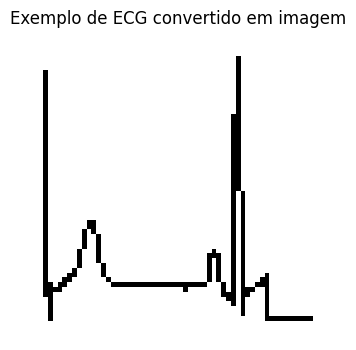

In [25]:
IMAGE_SIZE = 64

def signal_to_image(signal: np.ndarray, image_size: int = IMAGE_SIZE) -> np.ndarray:
    values = np.asarray(signal, dtype=np.float32)
    values = np.nan_to_num(values, nan=0.0)
    vmin, vmax = values.min(), values.max()
    if vmax - vmin < 1e-8:
        scaled = np.full_like(values, 0.5)
    else:
        scaled = (values - vmin) / (vmax - vmin)

    x_coords = np.linspace(4, image_size - 5, num=len(scaled))
    y_coords = (image_size - 5) - scaled * (image_size - 10)
    points = list(zip(x_coords.tolist(), y_coords.tolist()))

    image = Image.new('L', (image_size, image_size), color=255)
    draw = ImageDraw.Draw(image)
    draw.line(points, fill=0, width=1)

    return np.asarray(image, dtype=np.float32) / 255.0

sample_image = signal_to_image(X_signal[0])
plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap='gray')
plt.title('Exemplo de ECG convertido em imagem')
plt.axis('off')
plt.show()

## 5. Geração do conjunto de imagens

Nesta etapa, transformamos toda a base balanceada em imagens e preparamos os vetores achatados para alimentar a rede neural.

In [26]:
X_images = np.stack([signal_to_image(signal) for signal in X_signal]).astype(np.float32)
X_flat = X_images.reshape(len(X_images), -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (4000, 4096)
Teste: (1000, 4096)


## 6. Rede Neural MLP com Keras

A arquitetura abaixo usa camadas densas com `ReLU`, `Dropout` e saida sigmoide para classificação binária.

In [27]:
keras.utils.set_random_seed(RANDOM_STATE)

model = keras.Sequential([
    keras.layers.Input(shape=(IMAGE_SIZE * IMAGE_SIZE,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,081,857 (4.13 MB)

 Trainable params: 1,081,857 (4.13 MB)

 Non-trainable params: 0 (0.00 B)

### Treinamento do modelo e acompanhamento da acuracia

Nesta etapa, o modelo MLP e treinado com os dados de `X_train` e `y_train`, separando automaticamente 20% desse conjunto para validacao. Ao final, o grafico compara a acuracia de treino e de validacao ao longo das epocas, ajudando a verificar se o modelo esta aprendendo de forma consistente e se ha sinais de overfitting.

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5541 - loss: 0.9852 - val_accuracy: 0.7462 - val_loss: 0.6181
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6234 - loss: 0.6435 - val_accuracy: 0.7325 - val_loss: 0.5631
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6131 - loss: 0.6300 - val_accuracy: 0.6637 - val_loss: 0.6340
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6544 - loss: 0.6271 - val_accuracy: 0.7175 - val_loss: 0.6215
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6375 - loss: 0.6241 - val_accuracy: 0.6837 - val_loss: 0.6177
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6619 - loss: 0.6052 - val_accuracy: 0.7600 - val_loss: 0.5721
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6897 - loss: 0.5800 - val_accuracy: 0.7812 - val_loss: 0.5361
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6825 - loss: 0.5814 - val_accu

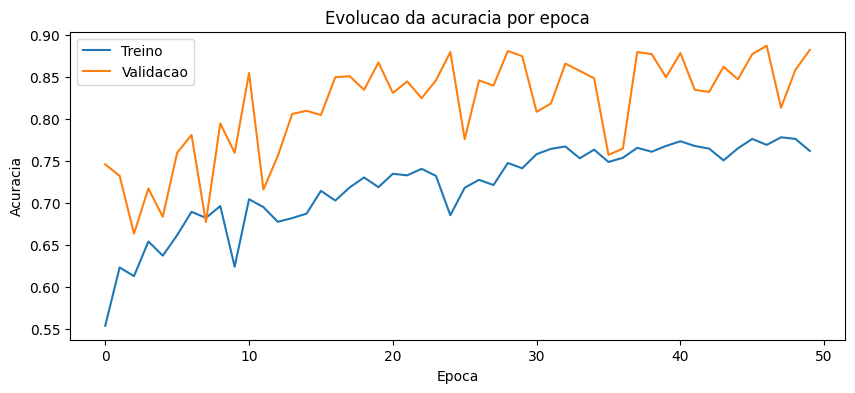

In [28]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1,
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validacao')
plt.title('Evolucao da acuracia por epoca')
plt.xlabel('Epoca')
plt.ylabel('Acuracia')
plt.legend()
plt.show()

## 7. Avaliacao

Calculamos a acuracia final e avaliamos o comportamento do classificador com matriz de confusao e relatorio textual.

Acuracia no teste: 0.8580

Relatorio de classificacao:

              precision    recall  f1-score   support

      normal       0.79      0.97      0.87       500
     anormal       0.97      0.74      0.84       500

    accuracy                           0.86      1000
   macro avg       0.88      0.86      0.86      1000
weighted avg       0.88      0.86      0.86      1000



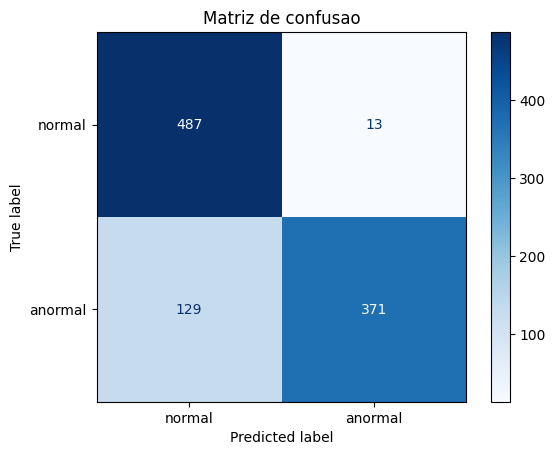

In [29]:
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print(f'Acuracia no teste: {acc:.4f}')
print('\nRelatorio de classificacao:\n')
print(classification_report(y_test, y_pred, target_names=['normal', 'anormal']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal', 'anormal'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusao')
plt.show()

## 8. Previsões de exemplo

Abaixo, mostramos alguns exames do conjunto de teste com o rótulo real e a previsão do modelo.

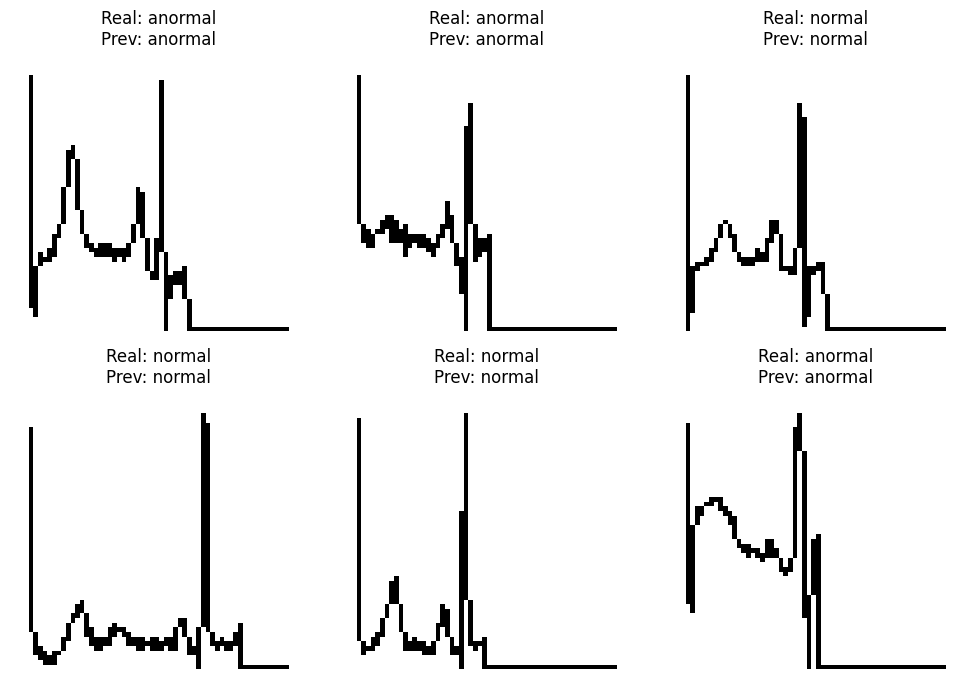

In [30]:
label_map = {0: 'normal', 1: 'anormal'}
indices = np.random.choice(len(X_test), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, idx in zip(axes.flatten(), indices):
    image = X_test[idx].reshape(IMAGE_SIZE, IMAGE_SIZE)
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Real: {label_map[y_test[idx]]}\nPrev: {label_map[y_pred[idx]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Conclusão

Com este fluxo, o `Ir Alem 2` demonstra uma abordagem completa de IA aplicada ao diagnóstico cardiológico:

- uso do dataset recomendado `heartbeat` do Kaggle;
- preprocessamento visual dos sinais em escala de cinza;
- treinamento de uma `MLP` com `Keras`;
- avaliação quantitativa do classificador.